In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path.cwd().parent))
import src.config as cfg
from src.stats_helpers import run_ttest_on_failures, run_chi_square_test

# Plotting style
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv(cfg.PROCESSED_DATA_FILE)

In [3]:
total_machines = len(df)
failed_machines = df[cfg.TARGET_COL].sum()
failure_rate = (failed_machines / total_machines) * 100

print(f"Overall Failure Rate: {failure_rate:.2f}% ({failed_machines} out of {total_machines} machines)")

print("\nBreakdown by Specific Failure Mode:")
for mode in cfg.FAILURE_MODES:
    mode_count = df[mode].sum()
    print(f" - {mode}: {mode_count} occurrences")

Overall Failure Rate: 3.39% (339 out of 10000 machines)

Breakdown by Specific Failure Mode:
 - TWF: 46 occurrences
 - HDF: 115 occurrences
 - PWF: 95 occurrences
 - OSF: 98 occurrences
 - RNF: 19 occurrences


In [4]:
theories_to_test = [
    # (Feature, Failure Mode)
    ("Torque [Nm]", "OSF"),          # Does high torque cause Overstrain Failure?
    ("Power [W]", "PWF"),            # Does high power cause Power Failure?
    ("Temp_Difference [K]", "HDF"),  # Does poor cooling cause Heat Dissipation Failure?
    ("Tool wear [min]", "TWF")       # Does long tool runtime cause Tool Wear Failure?
]

print("\n--- T-Test Results: Operating Conditions vs Failures ---")
results = []
for feature, mode in theories_to_test:
    res = run_ttest_on_failures(df, feature, mode)
    results.append(res)
    
results_df = pd.DataFrame(results)
display(results_df)


--- T-Test Results: Operating Conditions vs Failures ---


,Feature,Failure_Mode,Failed_Mean,Healthy_Mean,P_Value,Significant
0,Torque [Nm],OSF,58.37,39.80,3.460323e-53,True
1,Power [W],PWF,7251.82,6270.42,2.578654e-03,True
2,Temp_Difference [K],HDF,8.23,10.02,7.197135e-110,True
3,Tool wear [min],TWF,216.37,107.45,9.189013e-52,True


In [5]:
print("\n--- Chi-Square Result: Machine Quality Type vs Failure ---")
chi_res = run_chi_square_test(df, "Type", cfg.TARGET_COL)
display(pd.DataFrame([chi_res]))


--- Chi-Square Result: Machine Quality Type vs Failure ---


,Category,Failure_Mode,P_Value,Significant
0,Type,Machine failure,0.001032,True


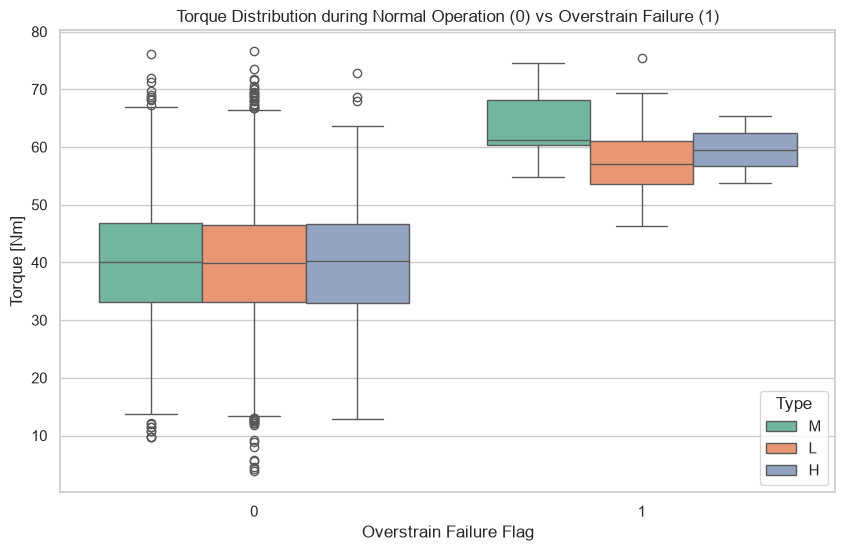

In [6]:
# Let's plot the most severe finding (usually Overstrain vs Torque)
plt.figure(figsize=(10, 6))
sns.boxplot(x="OSF", y="Torque [Nm]", data=df, hue="Type", palette="Set2")
plt.title("Torque Distribution during Normal Operation (0) vs Overstrain Failure (1)")
plt.xlabel("Overstrain Failure Flag")
plt.ylabel("Torque [Nm]")
plt.show()